In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Making encoded patch d > 2, we do not loose any information and perplexity does not collapse. When latent vector is flat, codebook usage is lower but not harms reconstruction

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 241.75it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 64
beta = 0.3
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)

num_epochs = 200
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 2 # adjustable encoder width for extra compression


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
mse = MeanSquaredError()
mse = mse.to(device)

In [10]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [11]:
event_train = events_train[:SELECTED_EVENTS][0]

In [12]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [13]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [14]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [15]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z, indexes: int):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        # z = z.permute(0, 2, 3, 1).contiguous()
        # z_flattened = z.view(-1, self.e_dim).contiguous()
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))
        
        z_q = z_q.reshape(-1, indexes, self.e_dim)

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [16]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [17]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [18]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    """
    d: int - how many codebook indexes could an encoded patch have    
    encoder_features: int - how many features are in encoder convolution output 
    
    """
    def __init__(self, d: int, slope: np.float64, latent_dim: int, encoder_features: int = 4) -> None:
        super().__init__()
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layers = nn.Sequential(
            nn.Linear(in_features=encoder_features, out_features=d),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        self.d = d
        
    def forward(self, x: torch.tensor) -> None:
        b, c, w, h = x.shape
        x_flattened = x.reshape(b, c, w * h)
        x_output = self.layers(x_flattened)
        (b, c, w) = x_output.shape
        x_output_flattened = x_output.reshape(b * w, c)
        return x_output_flattened.contiguous()
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - dinamically add required feature count for decoder
    
    """
    d: int - how many indexes could an encoded patch have
    decoder_features: int - how many features could a decoder convolution network have
    """
    
    def __init__(
        self, 
        d: int, 
        slope: np.float64, 
        decoder_features: int = 4,
    ) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=d, out_features=decoder_features),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        self.latent_dim = latent_dim
        self.decoder_features = decoder_features
        self.d = d
        
    def forward(self, x: torch.tensor) -> None:
        (b, w, c) = x.shape
        x = x.reshape(b, c, w)
        dec_out = self.layers(x)
        
        dec_out = dec_out.reshape(
            b,
            c,
            int(self.decoder_features**0.5),
            int(self.decoder_features**0.5)
        )
        return dec_out
    

In [19]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(d=d, slope=slope, latent_dim=latent_dim)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(d=d, slope=slope)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x, indexes):
        encoder_output = self.encoder(x)
        
        z = self.fc_encoder_input(encoder_output)
        # (b, c, d) -> (b * d, c)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z, indexes)
        
        z_q = self.fc_decoder_input(z_q)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [20]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d, # encoded patch indexes
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/200: 100%|██████████| 199/199 [00:00<00:00, 281.28it/s, Loss (BCE + VQ)=0.169] 


Epoch [1/200] summary:Average Loss: VQ + BCE = 0.1475,  Average loss: BCE = 0.0932 MSE = 0.010153366395520355 avg_perplexity = 3.9048012596877975
Average validation set BCE loss: 0.08928258419036865
Before compression (Training)
Shape: (13, 8, 8)


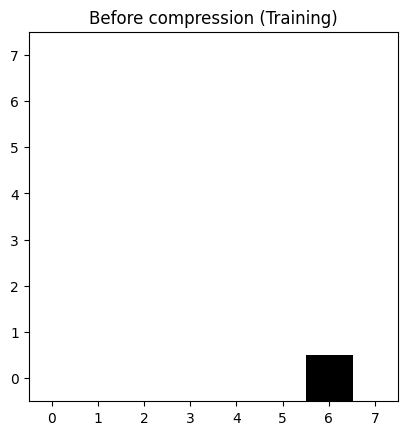

After compression (Training)
Shape: (1, 8, 8)


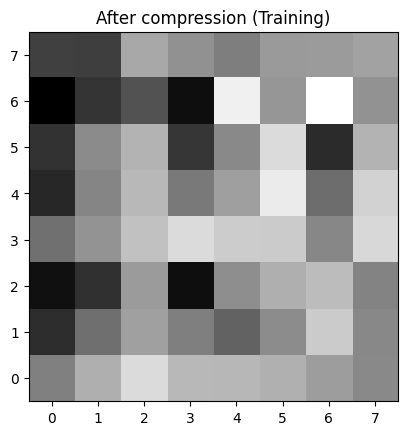

Epoch 2/200: 100%|██████████| 199/199 [00:00<00:00, 358.09it/s, Loss (BCE + VQ)=0.12]  


Epoch [2/200] summary:Average Loss: VQ + BCE = 0.0916,  Average loss: BCE = 0.0779 MSE = 0.008023987149810372 avg_perplexity = 6.845093172399243
Average validation set BCE loss: 0.06610027328133583


Epoch 3/200: 100%|██████████| 199/199 [00:00<00:00, 363.22it/s, Loss (BCE + VQ)=0.109] 


Epoch [3/200] summary:Average Loss: VQ + BCE = 0.0720,  Average loss: BCE = 0.0607 MSE = 0.00680108746775805 avg_perplexity = 16.04946527049769
Average validation set BCE loss: 0.05707043707370758


Epoch 4/200: 100%|██████████| 199/199 [00:00<00:00, 376.61it/s, Loss (BCE + VQ)=0.0825]


...

Epoch [14/200] summary:Average Loss: VQ + BCE = 0.0493,  Average loss: BCE = 0.0439 MSE = 0.004216580838901014 avg_perplexity = 40.057797599677464
Average validation set BCE loss: 0.044487695395946505


Epoch 15/200: 100%|██████████| 199/199 [00:00<00:00, 365.66it/s, Loss (BCE + VQ)=0.0542]


Epoch [15/200] summary:Average Loss: VQ + BCE = 0.0489,  Average loss: BCE = 0.0435 MSE = 0.004170087938917679 avg_perplexity = 40.980031257897764
Average validation set BCE loss: 0.04449614956974983


Epoch 16/200: 100%|██████████| 199/199 [00:00<00:00, 373.07it/s, Loss (BCE + VQ)=0.0972]


Epoch [16/200] summary:Average Loss: VQ + BCE = 0.0485,  Average loss: BCE = 0.0431 MSE = 0.004106602372938589 avg_perplexity = 41.80482721568352
Average validation set BCE loss: 0.044089026749134064
Before compression (Training)
Shape: (13, 8, 8)


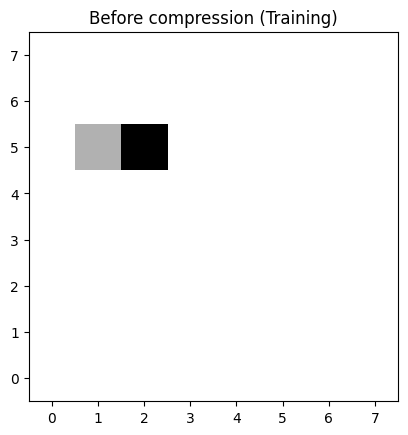

After compression (Training)
Shape: (1, 8, 8)


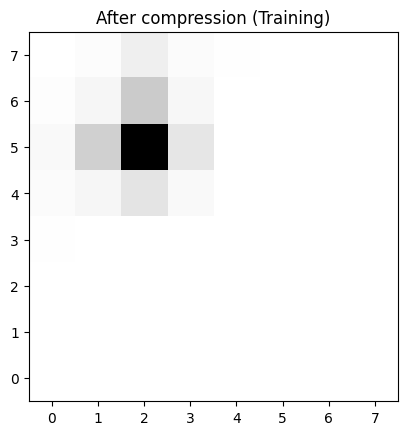

Epoch 17/200: 100%|██████████| 199/199 [00:00<00:00, 369.82it/s, Loss (BCE + VQ)=0.0511]


Epoch [17/200] summary:Average Loss: VQ + BCE = 0.0481,  Average loss: BCE = 0.0428 MSE = 0.0040518219592096515 avg_perplexity = 42.24900225538704
Average validation set BCE loss: 0.04430194944143295


Epoch 18/200: 100%|██████████| 199/199 [00:00<00:00, 362.49it/s, Loss (BCE + VQ)=0.053] 


Epoch [18/200] summary:Average Loss: VQ + BCE = 0.0487,  Average loss: BCE = 0.0432 MSE = 0.004120999712019634 avg_perplexity = 42.382687017546225
Average validation set BCE loss: 0.04456267058849335


Epoch 19/200: 100%|██████████| 199/199 [00:00<00:00, 372.86it/s, Loss (BCE + VQ)=0.0423]


...

Epoch [29/200] summary:Average Loss: VQ + BCE = 0.0454,  Average loss: BCE = 0.0404 MSE = 0.0036532070801298523 avg_perplexity = 45.64341551814247
Average validation set BCE loss: 0.04214596226811409


Epoch 30/200: 100%|██████████| 199/199 [00:00<00:00, 367.35it/s, Loss (BCE + VQ)=0.0433]


Epoch [30/200] summary:Average Loss: VQ + BCE = 0.0452,  Average loss: BCE = 0.0403 MSE = 0.0036091816918128847 avg_perplexity = 45.736055057851516
Average validation set BCE loss: 0.041682050377130506


Epoch 31/200: 100%|██████████| 199/199 [00:00<00:00, 376.58it/s, Loss (BCE + VQ)=0.0478]


Epoch [31/200] summary:Average Loss: VQ + BCE = 0.0452,  Average loss: BCE = 0.0402 MSE = 0.003601709641656609 avg_perplexity = 45.64963533411074
Average validation set BCE loss: 0.043253497779369356
Before compression (Training)
Shape: (13, 8, 8)


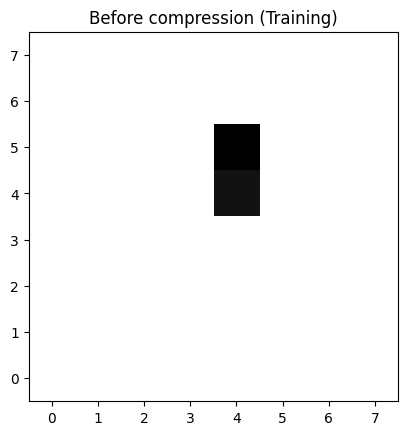

After compression (Training)
Shape: (1, 8, 8)


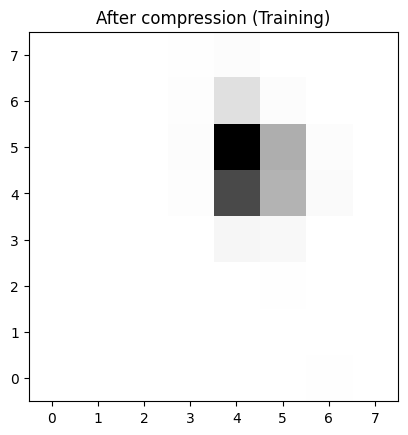

Epoch 32/200: 100%|██████████| 199/199 [00:00<00:00, 374.13it/s, Loss (BCE + VQ)=0.0485]


Epoch [32/200] summary:Average Loss: VQ + BCE = 0.0450,  Average loss: BCE = 0.0401 MSE = 0.003606668873526268 avg_perplexity = 45.98063285865975
Average validation set BCE loss: 0.042152372747659685


Epoch 33/200: 100%|██████████| 199/199 [00:00<00:00, 372.45it/s, Loss (BCE + VQ)=0.0428]


Epoch [33/200] summary:Average Loss: VQ + BCE = 0.0448,  Average loss: BCE = 0.0399 MSE = 0.003589483938558991 avg_perplexity = 45.68019900489692
Average validation set BCE loss: 0.04162692800164223


Epoch 34/200: 100%|██████████| 199/199 [00:00<00:00, 367.19it/s, Loss (BCE + VQ)=0.0676]


...

Epoch [44/200] summary:Average Loss: VQ + BCE = 0.0439,  Average loss: BCE = 0.0392 MSE = 0.003462151599692265 avg_perplexity = 46.55927389710393
Average validation set BCE loss: 0.0412296749651432


Epoch 45/200: 100%|██████████| 199/199 [00:00<00:00, 376.80it/s, Loss (BCE + VQ)=0.0566]


Epoch [45/200] summary:Average Loss: VQ + BCE = 0.0440,  Average loss: BCE = 0.0392 MSE = 0.003481087595430301 avg_perplexity = 46.375679409084604
Average validation set BCE loss: 0.041519745439291


Epoch 46/200: 100%|██████████| 199/199 [00:00<00:00, 372.13it/s, Loss (BCE + VQ)=0.0602]


Epoch [46/200] summary:Average Loss: VQ + BCE = 0.0436,  Average loss: BCE = 0.0389 MSE = 0.0034023261501514657 avg_perplexity = 45.96735935115335
Average validation set BCE loss: 0.04135378524661064
Before compression (Training)
Shape: (13, 8, 8)


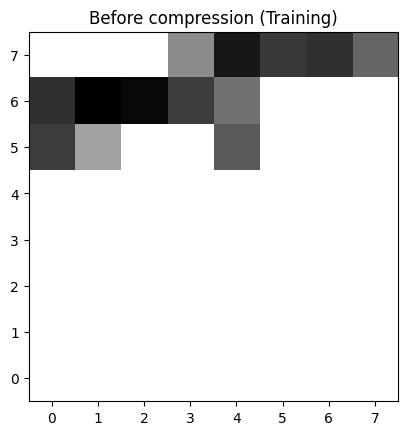

After compression (Training)
Shape: (1, 8, 8)


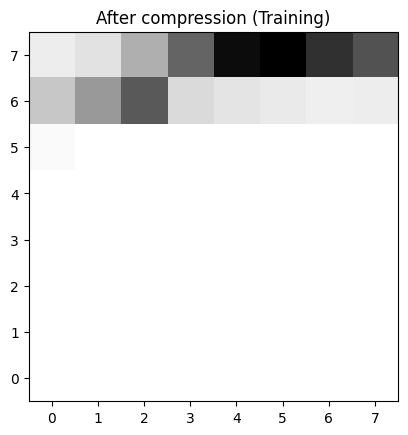

Epoch 47/200: 100%|██████████| 199/199 [00:00<00:00, 372.58it/s, Loss (BCE + VQ)=0.0479]


Epoch [47/200] summary:Average Loss: VQ + BCE = 0.0432,  Average loss: BCE = 0.0387 MSE = 0.0033873854972534443 avg_perplexity = 46.50469662076864
Average validation set BCE loss: 0.04076906591653824


Epoch 48/200: 100%|██████████| 199/199 [00:00<00:00, 368.79it/s, Loss (BCE + VQ)=0.0396]


Epoch [48/200] summary:Average Loss: VQ + BCE = 0.0430,  Average loss: BCE = 0.0385 MSE = 0.0033574345177647905 avg_perplexity = 46.31700453446738
Average validation set BCE loss: 0.04129970669746399


Epoch 49/200: 100%|██████████| 199/199 [00:00<00:00, 378.21it/s, Loss (BCE + VQ)=0.0607]


...

Epoch [59/200] summary:Average Loss: VQ + BCE = 0.0426,  Average loss: BCE = 0.0380 MSE = 0.0032843761298168993 avg_perplexity = 46.82612059703424
Average validation set BCE loss: 0.04061860591173172


Epoch 60/200: 100%|██████████| 199/199 [00:00<00:00, 371.99it/s, Loss (BCE + VQ)=0.0466]


Epoch [60/200] summary:Average Loss: VQ + BCE = 0.0426,  Average loss: BCE = 0.0380 MSE = 0.0032697650387499425 avg_perplexity = 46.63187842632658
Average validation set BCE loss: 0.04072216376662254


Epoch 61/200: 100%|██████████| 199/199 [00:00<00:00, 367.91it/s, Loss (BCE + VQ)=0.0608]


Epoch [61/200] summary:Average Loss: VQ + BCE = 0.0424,  Average loss: BCE = 0.0378 MSE = 0.00322487536436368 avg_perplexity = 46.92456773537487
Average validation set BCE loss: 0.040586188435554504
Before compression (Training)
Shape: (13, 8, 8)


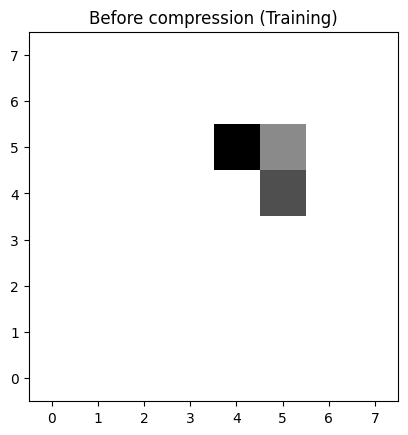

After compression (Training)
Shape: (1, 8, 8)


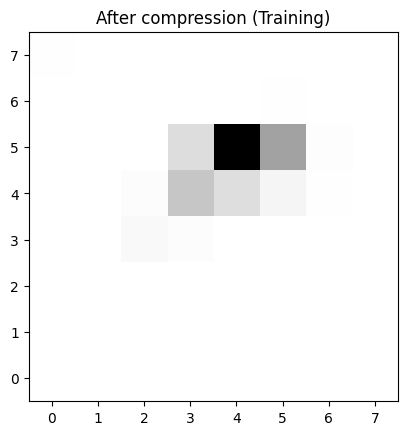

Epoch 62/200: 100%|██████████| 199/199 [00:00<00:00, 364.30it/s, Loss (BCE + VQ)=0.0572]


Epoch [62/200] summary:Average Loss: VQ + BCE = 0.0424,  Average loss: BCE = 0.0379 MSE = 0.003257759564776142 avg_perplexity = 46.57603550436509
Average validation set BCE loss: 0.04146690592169762


Epoch 63/200: 100%|██████████| 199/199 [00:00<00:00, 363.04it/s, Loss (BCE + VQ)=0.0551]


Epoch [63/200] summary:Average Loss: VQ + BCE = 0.0425,  Average loss: BCE = 0.0379 MSE = 0.003258554609469021 avg_perplexity = 46.70203119785941
Average validation set BCE loss: 0.0403654932975769


Epoch 64/200: 100%|██████████| 199/199 [00:00<00:00, 372.64it/s, Loss (BCE + VQ)=0.0484]


...

Epoch [74/200] summary:Average Loss: VQ + BCE = 0.0417,  Average loss: BCE = 0.0374 MSE = 0.0031575274960273622 avg_perplexity = 47.09181614976433
Average validation set BCE loss: 0.040547913312911986


Epoch 75/200: 100%|██████████| 199/199 [00:00<00:00, 375.28it/s, Loss (BCE + VQ)=0.0462]


Epoch [75/200] summary:Average Loss: VQ + BCE = 0.0418,  Average loss: BCE = 0.0374 MSE = 0.0031645157638862356 avg_perplexity = 46.43593770894573
Average validation set BCE loss: 0.040179362148046495


Epoch 76/200: 100%|██████████| 199/199 [00:00<00:00, 362.85it/s, Loss (BCE + VQ)=0.0308]


Epoch [76/200] summary:Average Loss: VQ + BCE = 0.0417,  Average loss: BCE = 0.0373 MSE = 0.003127790163224329 avg_perplexity = 46.390577249191516
Average validation set BCE loss: 0.04109905734658241
Before compression (Training)
Shape: (13, 8, 8)


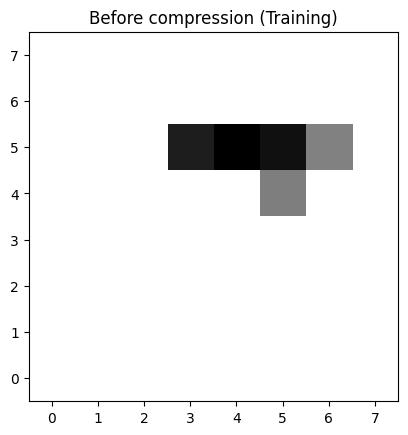

After compression (Training)
Shape: (1, 8, 8)


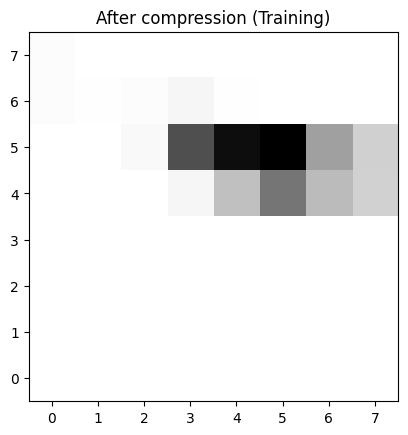

Epoch 77/200: 100%|██████████| 199/199 [00:00<00:00, 363.86it/s, Loss (BCE + VQ)=0.0558]


Epoch [77/200] summary:Average Loss: VQ + BCE = 0.0418,  Average loss: BCE = 0.0374 MSE = 0.0031556842483617554 avg_perplexity = 46.24062188306645
Average validation set BCE loss: 0.0416937954723835


Epoch 78/200: 100%|██████████| 199/199 [00:00<00:00, 369.93it/s, Loss (BCE + VQ)=0.0385]


Epoch [78/200] summary:Average Loss: VQ + BCE = 0.0418,  Average loss: BCE = 0.0373 MSE = 0.0031519094359213906 avg_perplexity = 46.32629329355518
Average validation set BCE loss: 0.04056423306465149


Epoch 79/200: 100%|██████████| 199/199 [00:00<00:00, 369.55it/s, Loss (BCE + VQ)=0.0497]


...

Epoch [89/200] summary:Average Loss: VQ + BCE = 0.0411,  Average loss: BCE = 0.0369 MSE = 0.003059084493264406 avg_perplexity = 46.78194644103697
Average validation set BCE loss: 0.04051681011915207


Epoch 90/200: 100%|██████████| 199/199 [00:00<00:00, 353.46it/s, Loss (BCE + VQ)=0.0331]


Epoch [90/200] summary:Average Loss: VQ + BCE = 0.0408,  Average loss: BCE = 0.0366 MSE = 0.0030128559286018188 avg_perplexity = 46.98912227573107
Average validation set BCE loss: 0.040307840704917906


Epoch 91/200: 100%|██████████| 199/199 [00:00<00:00, 357.70it/s, Loss (BCE + VQ)=0.0419]


Epoch [91/200] summary:Average Loss: VQ + BCE = 0.0410,  Average loss: BCE = 0.0368 MSE = 0.0030553408122701037 avg_perplexity = 47.24112768508681
Average validation set BCE loss: 0.040362507849931714
Before compression (Training)
Shape: (13, 8, 8)


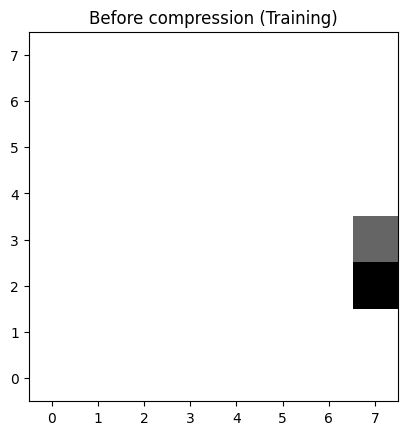

After compression (Training)
Shape: (1, 8, 8)


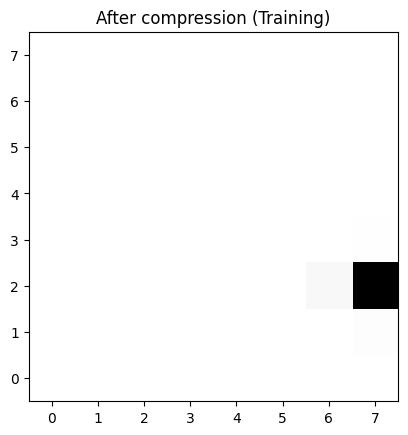

Epoch 92/200: 100%|██████████| 199/199 [00:00<00:00, 367.21it/s, Loss (BCE + VQ)=0.0355]


Epoch [92/200] summary:Average Loss: VQ + BCE = 0.0408,  Average loss: BCE = 0.0367 MSE = 0.003031032135939441 avg_perplexity = 46.96051720278946
Average validation set BCE loss: 0.039919453859329226


Epoch 93/200: 100%|██████████| 199/199 [00:00<00:00, 371.23it/s, Loss (BCE + VQ)=0.0524]


Epoch [93/200] summary:Average Loss: VQ + BCE = 0.0406,  Average loss: BCE = 0.0365 MSE = 0.002989346340495213 avg_perplexity = 47.070348413745364
Average validation set BCE loss: 0.04030139222741127


Epoch 94/200: 100%|██████████| 199/199 [00:00<00:00, 372.64it/s, Loss (BCE + VQ)=0.0471]


...

Epoch [104/200] summary:Average Loss: VQ + BCE = 0.0414,  Average loss: BCE = 0.0371 MSE = 0.00309189945522546 avg_perplexity = 46.86953766022495
Average validation set BCE loss: 0.03979873433709145


Epoch 105/200: 100%|██████████| 199/199 [00:00<00:00, 364.09it/s, Loss (BCE + VQ)=0.0399]


Epoch [105/200] summary:Average Loss: VQ + BCE = 0.0406,  Average loss: BCE = 0.0365 MSE = 0.00298410107793483 avg_perplexity = 47.225849017426
Average validation set BCE loss: 0.03956961333751678


Epoch 106/200: 100%|██████████| 199/199 [00:00<00:00, 368.32it/s, Loss (BCE + VQ)=0.0353]


Epoch [106/200] summary:Average Loss: VQ + BCE = 0.0405,  Average loss: BCE = 0.0364 MSE = 0.0029707511397892954 avg_perplexity = 47.31250138977664
Average validation set BCE loss: 0.03964140713214874
Before compression (Training)
Shape: (13, 8, 8)


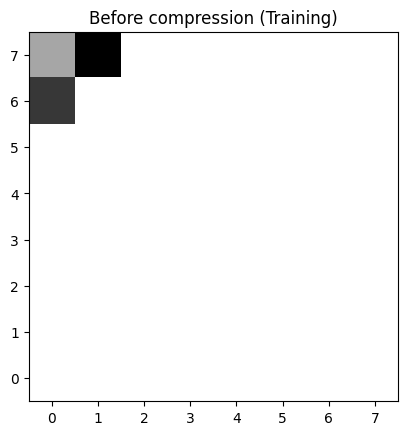

After compression (Training)
Shape: (1, 8, 8)


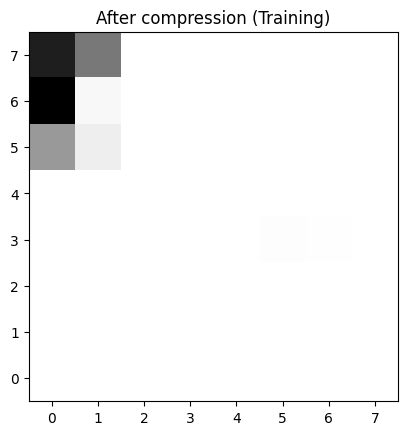

Epoch 107/200: 100%|██████████| 199/199 [00:00<00:00, 372.70it/s, Loss (BCE + VQ)=0.0516]


Epoch [107/200] summary:Average Loss: VQ + BCE = 0.0406,  Average loss: BCE = 0.0365 MSE = 0.0029864934806585614 avg_perplexity = 47.17317735489888
Average validation set BCE loss: 0.04015106856822968


Epoch 108/200: 100%|██████████| 199/199 [00:00<00:00, 372.27it/s, Loss (BCE + VQ)=0.0488]


Epoch [108/200] summary:Average Loss: VQ + BCE = 0.0403,  Average loss: BCE = 0.0364 MSE = 0.0029417875377302193 avg_perplexity = 47.35168054475257
Average validation set BCE loss: 0.04029637202620506


Epoch 109/200: 100%|██████████| 199/199 [00:00<00:00, 370.15it/s, Loss (BCE + VQ)=0.0349]


...

Epoch [119/200] summary:Average Loss: VQ + BCE = 0.0403,  Average loss: BCE = 0.0363 MSE = 0.0029357531202732394 avg_perplexity = 47.562299009543565
Average validation set BCE loss: 0.039872007071971895


Epoch 120/200: 100%|██████████| 199/199 [00:00<00:00, 356.15it/s, Loss (BCE + VQ)=0.0347]


Epoch [120/200] summary:Average Loss: VQ + BCE = 0.0404,  Average loss: BCE = 0.0364 MSE = 0.0029578486231656453 avg_perplexity = 47.62290914334245
Average validation set BCE loss: 0.0401295468211174


Epoch 121/200: 100%|██████████| 199/199 [00:00<00:00, 370.87it/s, Loss (BCE + VQ)=0.0357]


Epoch [121/200] summary:Average Loss: VQ + BCE = 0.0403,  Average loss: BCE = 0.0363 MSE = 0.0029135403590716757 avg_perplexity = 47.58882318429612
Average validation set BCE loss: 0.04332654923200607
Before compression (Training)
Shape: (13, 8, 8)


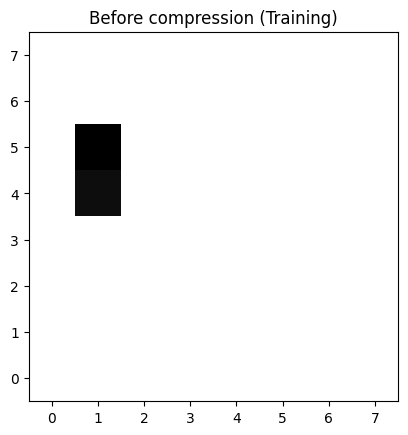

After compression (Training)
Shape: (1, 8, 8)


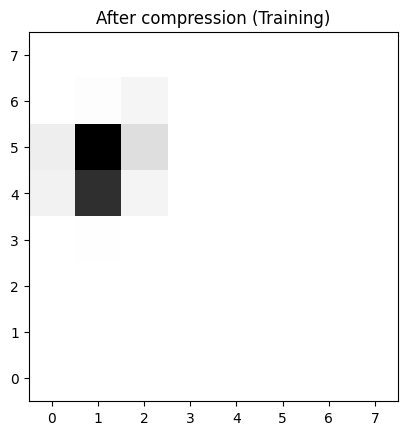

Epoch 122/200: 100%|██████████| 199/199 [00:00<00:00, 356.47it/s, Loss (BCE + VQ)=0.0511]


Epoch [122/200] summary:Average Loss: VQ + BCE = 0.0402,  Average loss: BCE = 0.0362 MSE = 0.0029003587340814384 avg_perplexity = 47.48708928170516
Average validation set BCE loss: 0.0423042543232441


Epoch 123/200: 100%|██████████| 199/199 [00:00<00:00, 358.47it/s, Loss (BCE + VQ)=0.0455]


Epoch [123/200] summary:Average Loss: VQ + BCE = 0.0402,  Average loss: BCE = 0.0362 MSE = 0.0029023389973158215 avg_perplexity = 47.775407628198366
Average validation set BCE loss: 0.04004501104354859


Epoch 124/200: 100%|██████████| 199/199 [00:00<00:00, 361.44it/s, Loss (BCE + VQ)=0.0399]


...

Epoch [134/200] summary:Average Loss: VQ + BCE = 0.0398,  Average loss: BCE = 0.0359 MSE = 0.002843881291501112 avg_perplexity = 47.423937054734736
Average validation set BCE loss: 0.04104487150907517


Epoch 135/200: 100%|██████████| 199/199 [00:00<00:00, 364.02it/s, Loss (BCE + VQ)=0.0408]


Epoch [135/200] summary:Average Loss: VQ + BCE = 0.0399,  Average loss: BCE = 0.0359 MSE = 0.0028504210784001715 avg_perplexity = 47.47346941310557
Average validation set BCE loss: 0.04255372509360313


Epoch 136/200: 100%|██████████| 199/199 [00:00<00:00, 366.28it/s, Loss (BCE + VQ)=0.0324]


Epoch [136/200] summary:Average Loss: VQ + BCE = 0.0398,  Average loss: BCE = 0.0359 MSE = 0.002854803654870683 avg_perplexity = 47.547945789356326
Average validation set BCE loss: 0.04095371589064598
Before compression (Training)
Shape: (13, 8, 8)


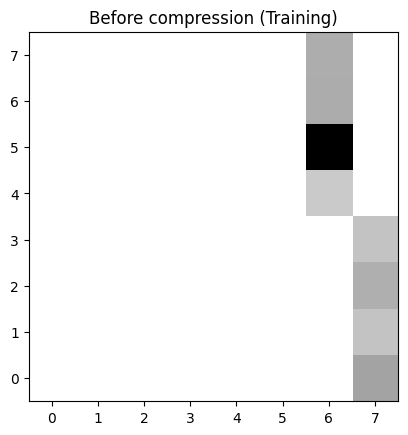

After compression (Training)
Shape: (1, 8, 8)


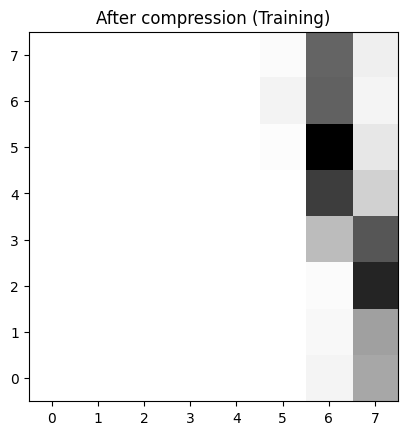

Epoch 137/200: 100%|██████████| 199/199 [00:00<00:00, 352.18it/s, Loss (BCE + VQ)=0.0515]


Epoch [137/200] summary:Average Loss: VQ + BCE = 0.0397,  Average loss: BCE = 0.0358 MSE = 0.002845213877215008 avg_perplexity = 47.451398609870644
Average validation set BCE loss: 0.04352635964751243


Epoch 138/200: 100%|██████████| 199/199 [00:00<00:00, 361.84it/s, Loss (BCE + VQ)=0.0379]


Epoch [138/200] summary:Average Loss: VQ + BCE = 0.0398,  Average loss: BCE = 0.0359 MSE = 0.0028582000420499013 avg_perplexity = 47.52688248792485
Average validation set BCE loss: 0.04087766855955124


Epoch 139/200: 100%|██████████| 199/199 [00:00<00:00, 356.70it/s, Loss (BCE + VQ)=0.0475]


...

Epoch [149/200] summary:Average Loss: VQ + BCE = 0.0397,  Average loss: BCE = 0.0358 MSE = 0.002827787393324976 avg_perplexity = 47.77771351684877
Average validation set BCE loss: 0.04266907498240471


Epoch 150/200: 100%|██████████| 199/199 [00:00<00:00, 369.46it/s, Loss (BCE + VQ)=0.0549]


Epoch [150/200] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0357 MSE = 0.0028144202888919856 avg_perplexity = 48.176960355672406
Average validation set BCE loss: 0.041436570882797244


Epoch 151/200: 100%|██████████| 199/199 [00:00<00:00, 367.39it/s, Loss (BCE + VQ)=0.0498]


Epoch [151/200] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0357 MSE = 0.0028141158259703063 avg_perplexity = 48.18677585927685
Average validation set BCE loss: 0.04127991273999214
Before compression (Training)
Shape: (13, 8, 8)


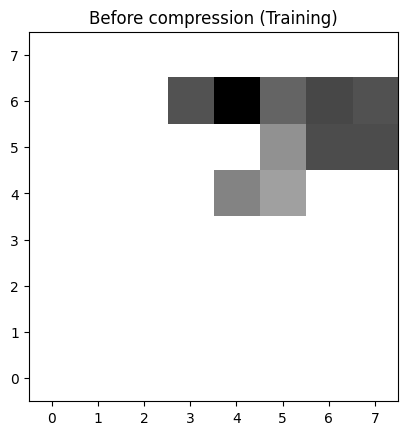

After compression (Training)
Shape: (1, 8, 8)


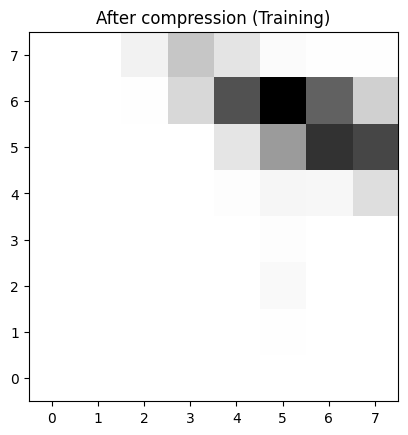

Epoch 152/200: 100%|██████████| 199/199 [00:00<00:00, 365.36it/s, Loss (BCE + VQ)=0.0526]


Epoch [152/200] summary:Average Loss: VQ + BCE = 0.0394,  Average loss: BCE = 0.0356 MSE = 0.0027894869349644187 avg_perplexity = 48.13951106047511
Average validation set BCE loss: 0.04100843146443367


Epoch 153/200: 100%|██████████| 199/199 [00:00<00:00, 347.31it/s, Loss (BCE + VQ)=0.0593]


Epoch [153/200] summary:Average Loss: VQ + BCE = 0.0399,  Average loss: BCE = 0.0359 MSE = 0.0028433502638881007 avg_perplexity = 48.13436215846383
Average validation set BCE loss: 0.04170161113142967


Epoch 154/200: 100%|██████████| 199/199 [00:00<00:00, 364.11it/s, Loss (BCE + VQ)=0.0293]


...

Epoch [164/200] summary:Average Loss: VQ + BCE = 0.0393,  Average loss: BCE = 0.0354 MSE = 0.002759760988632863 avg_perplexity = 48.45059275028095
Average validation set BCE loss: 0.041623391956090924


Epoch 165/200: 100%|██████████| 199/199 [00:00<00:00, 364.19it/s, Loss (BCE + VQ)=0.0337]


Epoch [165/200] summary:Average Loss: VQ + BCE = 0.0394,  Average loss: BCE = 0.0355 MSE = 0.0027664350076630037 avg_perplexity = 48.91983059063629
Average validation set BCE loss: 0.04073290228843689


Epoch 166/200: 100%|██████████| 199/199 [00:00<00:00, 365.22it/s, Loss (BCE + VQ)=0.0332]


Epoch [166/200] summary:Average Loss: VQ + BCE = 0.0391,  Average loss: BCE = 0.0353 MSE = 0.00273726393829039 avg_perplexity = 48.80471036901426
Average validation set BCE loss: 0.04138295650482178
Before compression (Training)
Shape: (13, 8, 8)


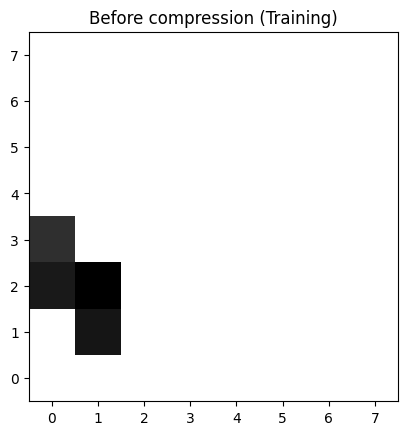

After compression (Training)
Shape: (1, 8, 8)


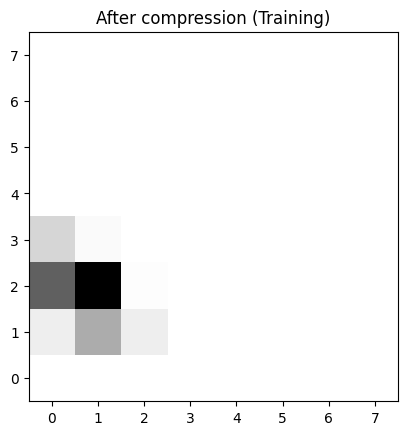

Epoch 167/200: 100%|██████████| 199/199 [00:00<00:00, 366.66it/s, Loss (BCE + VQ)=0.0542]


Epoch [167/200] summary:Average Loss: VQ + BCE = 0.0394,  Average loss: BCE = 0.0355 MSE = 0.002776265022667808 avg_perplexity = 49.25615551244074
Average validation set BCE loss: 0.041184176504611966


Epoch 168/200: 100%|██████████| 199/199 [00:00<00:00, 362.18it/s, Loss (BCE + VQ)=0.0278]


Epoch [168/200] summary:Average Loss: VQ + BCE = 0.0391,  Average loss: BCE = 0.0352 MSE = 0.0027225224351529126 avg_perplexity = 49.30435197916462
Average validation set BCE loss: 0.041515327990055084


Epoch 169/200: 100%|██████████| 199/199 [00:00<00:00, 367.76it/s, Loss (BCE + VQ)=0.0328]


...

Epoch [179/200] summary:Average Loss: VQ + BCE = 0.0390,  Average loss: BCE = 0.0352 MSE = 0.002692910484576495 avg_perplexity = 48.89978499867808
Average validation set BCE loss: 0.04235565736889839


Epoch 180/200: 100%|██████████| 199/199 [00:00<00:00, 372.81it/s, Loss (BCE + VQ)=0.0591]


Epoch [180/200] summary:Average Loss: VQ + BCE = 0.0391,  Average loss: BCE = 0.0352 MSE = 0.0027321279862071927 avg_perplexity = 48.985916080187316
Average validation set BCE loss: 0.04326573759317398


Epoch 181/200: 100%|██████████| 199/199 [00:00<00:00, 356.09it/s, Loss (BCE + VQ)=0.039] 


Epoch [181/200] summary:Average Loss: VQ + BCE = 0.0392,  Average loss: BCE = 0.0353 MSE = 0.002713176912637474 avg_perplexity = 49.030752546224164
Average validation set BCE loss: 0.04069301635026932
Before compression (Training)
Shape: (13, 8, 8)


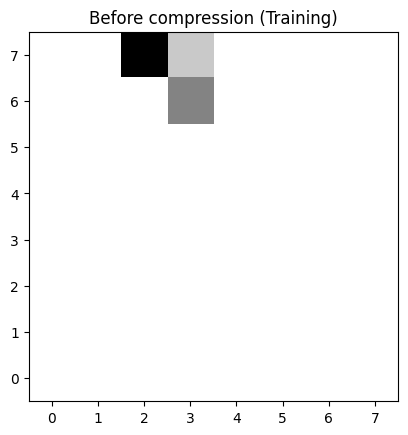

After compression (Training)
Shape: (1, 8, 8)


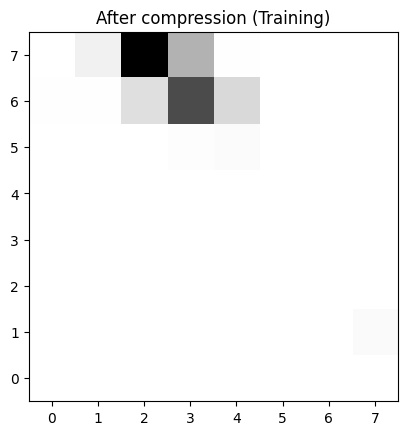

Epoch 182/200: 100%|██████████| 199/199 [00:00<00:00, 361.60it/s, Loss (BCE + VQ)=0.0465]


Epoch [182/200] summary:Average Loss: VQ + BCE = 0.0392,  Average loss: BCE = 0.0352 MSE = 0.002716989658337704 avg_perplexity = 48.791899187480986
Average validation set BCE loss: 0.04150993749499321


Epoch 183/200: 100%|██████████| 199/199 [00:00<00:00, 363.62it/s, Loss (BCE + VQ)=0.0404]


Epoch [183/200] summary:Average Loss: VQ + BCE = 0.0392,  Average loss: BCE = 0.0353 MSE = 0.002709089255372259 avg_perplexity = 48.78223155611124
Average validation set BCE loss: 0.04062391221523285


Epoch 184/200: 100%|██████████| 199/199 [00:00<00:00, 363.01it/s, Loss (BCE + VQ)=0.0456]


...

Epoch [194/200] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0348 MSE = 0.0026271694512972283 avg_perplexity = 50.37377087195315
Average validation set BCE loss: 0.04293966516852379


Epoch 195/200: 100%|██████████| 199/199 [00:00<00:00, 354.13it/s, Loss (BCE + VQ)=0.0412]


Epoch [195/200] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0348 MSE = 0.002649906496798161 avg_perplexity = 50.2049822591657
Average validation set BCE loss: 0.04173745661973953


Epoch 196/200: 100%|██████████| 199/199 [00:00<00:00, 359.99it/s, Loss (BCE + VQ)=0.0328]


Epoch [196/200] summary:Average Loss: VQ + BCE = 0.0387,  Average loss: BCE = 0.0349 MSE = 0.002645514259610943 avg_perplexity = 50.50127546990936
Average validation set BCE loss: 0.04279901683330536
Before compression (Training)
Shape: (13, 8, 8)


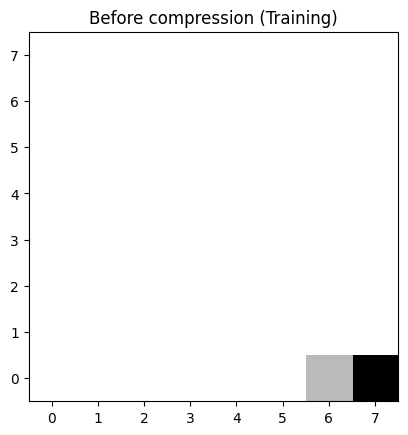

After compression (Training)
Shape: (1, 8, 8)


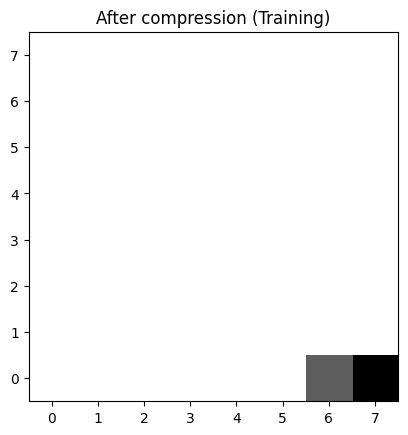

Epoch 197/200: 100%|██████████| 199/199 [00:00<00:00, 360.47it/s, Loss (BCE + VQ)=0.0304]


Epoch [197/200] summary:Average Loss: VQ + BCE = 0.0388,  Average loss: BCE = 0.0349 MSE = 0.002644215856711544 avg_perplexity = 50.02891219441016
Average validation set BCE loss: 0.03998104929924011


Epoch 198/200: 100%|██████████| 199/199 [00:00<00:00, 370.63it/s, Loss (BCE + VQ)=0.0295]


Epoch [198/200] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0348 MSE = 0.00264658915445246 avg_perplexity = 50.48129566710199
Average validation set BCE loss: 0.0424110621213913


Epoch 199/200: 100%|██████████| 199/199 [00:00<00:00, 374.94it/s, Loss (BCE + VQ)=0.0361]


Epoch [199/200] summary:Average Loss: VQ + BCE = 0.0385,  Average loss: BCE = 0.0348 MSE = 0.0026186999236584535 avg_perplexity = 50.37723797170361
Average validation set BCE loss: 0.04301905259490013


Epoch 200/200: 100%|██████████| 199/199 [00:00<00:00, 368.06it/s, Loss (BCE + VQ)=0.0366]


Epoch [200/200] summary:Average Loss: VQ + BCE = 0.0386,  Average loss: BCE = 0.0349 MSE = 0.0026562532875686884 avg_perplexity = 50.36138517293499
Average validation set BCE loss: 0.042955723404884336


TypeError: VQVAE.forward() missing 1 required positional argument: 'indexes'

In [ ]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs,
           d
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val, d)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val, d)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val.shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------width_val------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
            
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(d, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        d,
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [ ]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


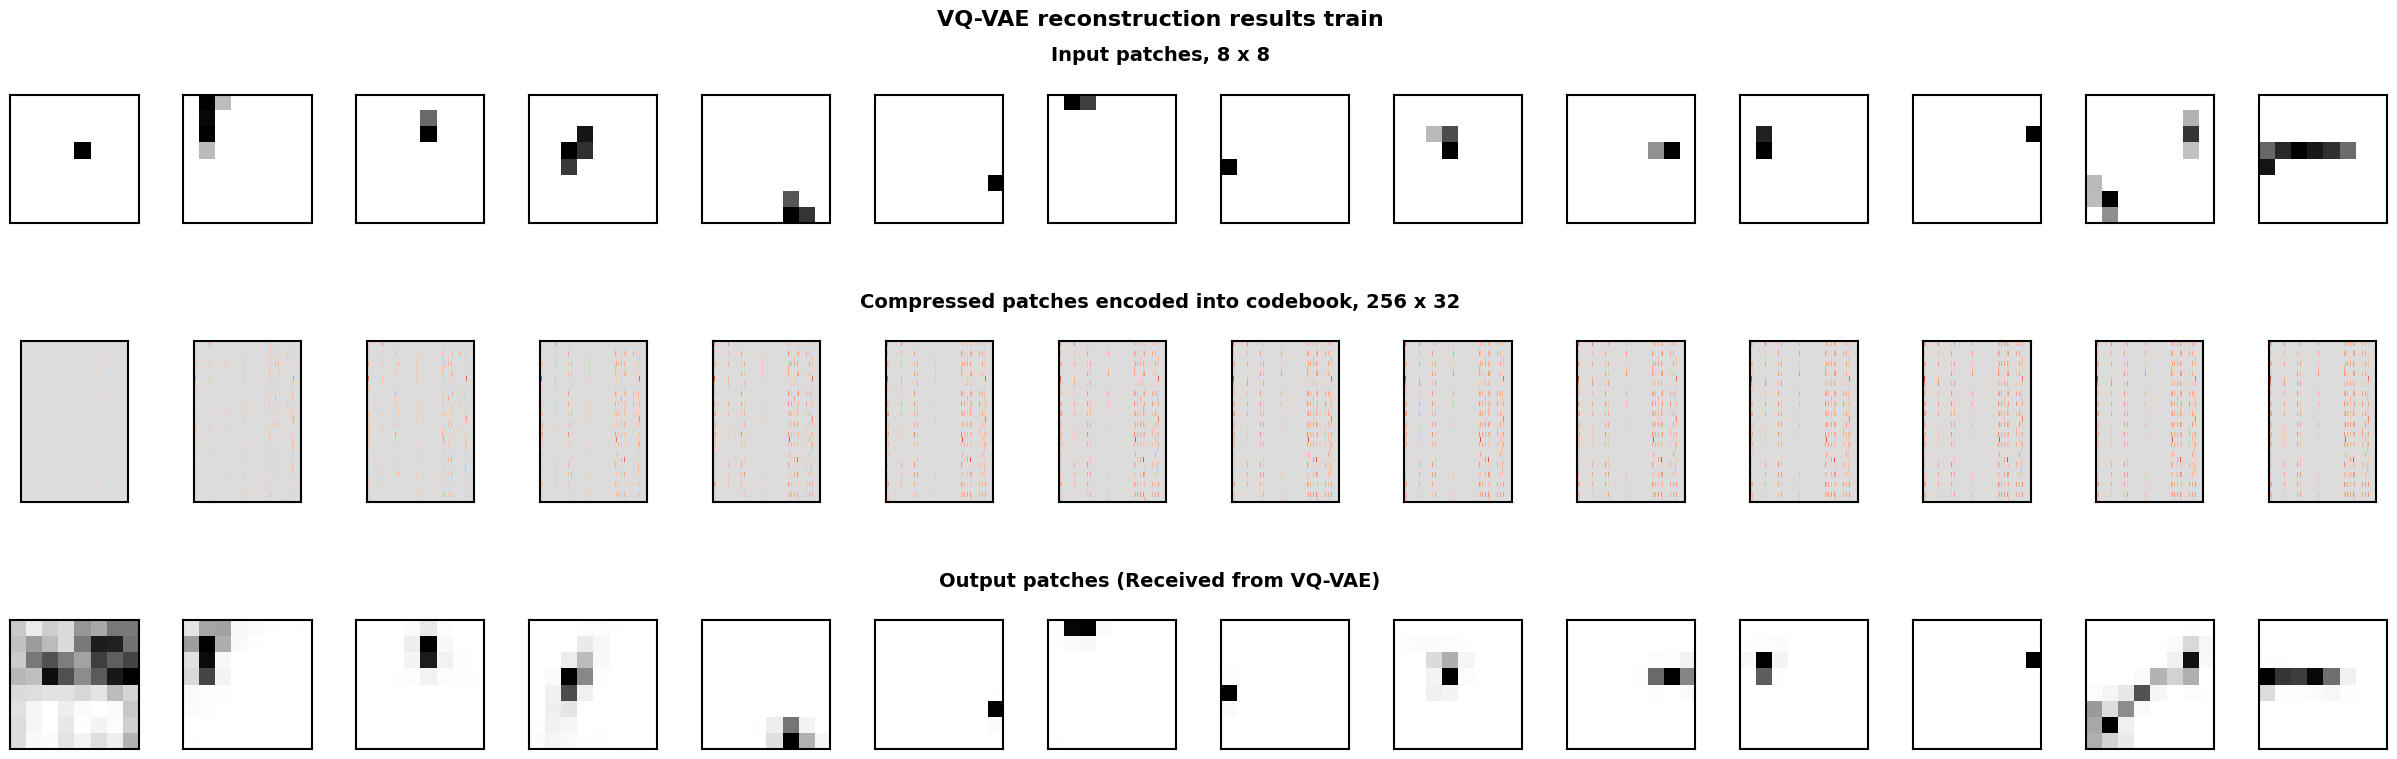

In [ ]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

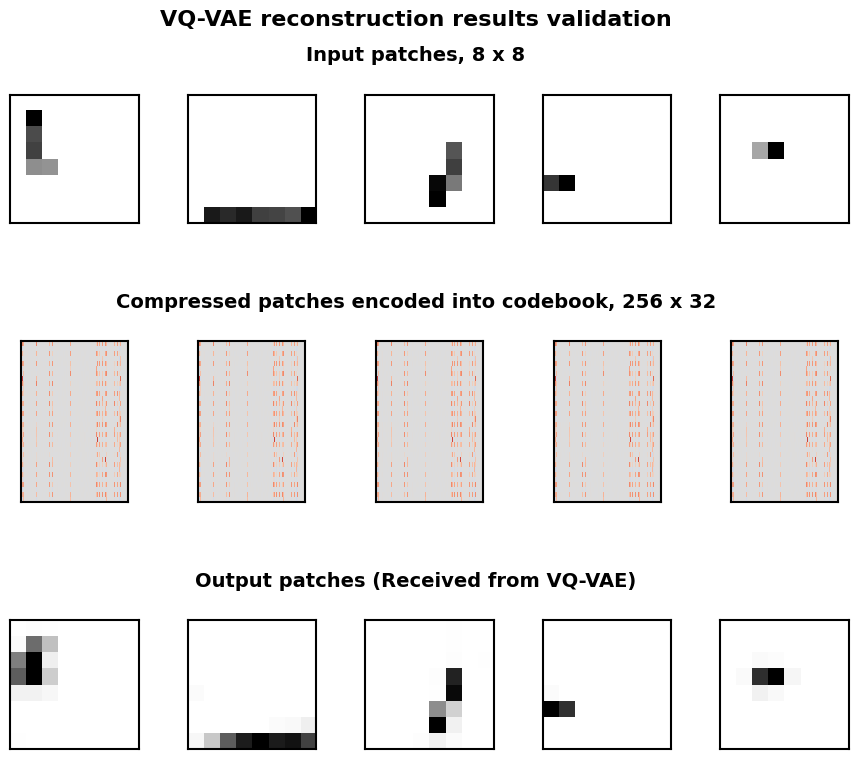

In [ ]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [ ]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.03674666956067085
encoder.1.weight 0.004832393955439329
encoder.1.bias 0.008109470829367638
encoder.3.weight 0.13348610699176788
encoder.4.weight 0.004398836754262447
encoder.4.bias 0.0046499744057655334
encoder.6.weight 0.14785514771938324
encoder.7.weight 0.005836995784193277
encoder.7.bias 0.007267244625836611
encoder.8.stack.0.res_block.1.weight 0.030796067789196968
encoder.8.stack.0.res_block.3.weight 0.015569343231618404
encoder.8.stack.1.res_block.1.weight 0.03335775062441826
encoder.8.stack.1.res_block.3.weight 0.01939585618674755
fc_encoder_input.layers.0.weight 0.007341883145272732
fc_encoder_input.layers.0.bias 9.285535895742214e-09
fc_encoder_input.layers.1.weight 0.014589500613510609
fc_encoder_input.layers.1.bias 0.005194962024688721
vq_layer.embedding.weight 0.000625808082986623
fc_decoder_input.layers.0.weight 0.006798907648772001
fc_decoder_input.layers.0.bias 7.471506080491963e-08
fc_decoder_input.layers.1.weight 0.0031712693

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


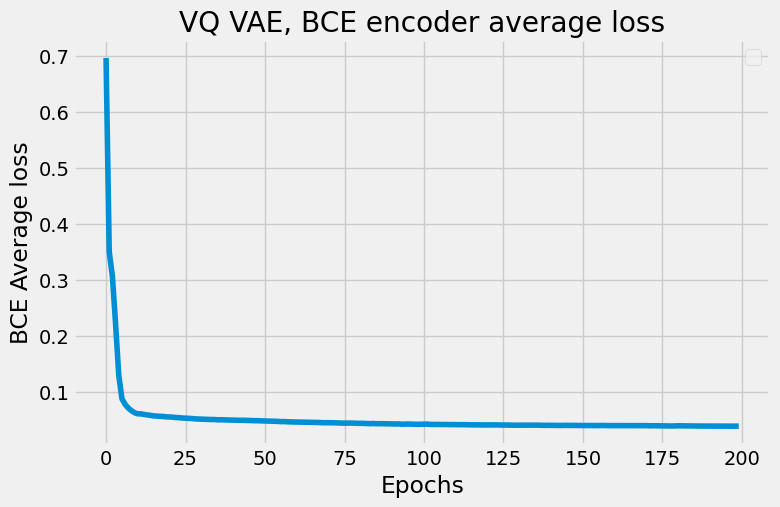

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [ ]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [ ]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("../bin/vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test, d)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.36730
Based on test set (size = 45), average codebook perplexity = 25.65656/256
Saved VQ-VAE test results


In [ ]:
len(patches_before_test)

6

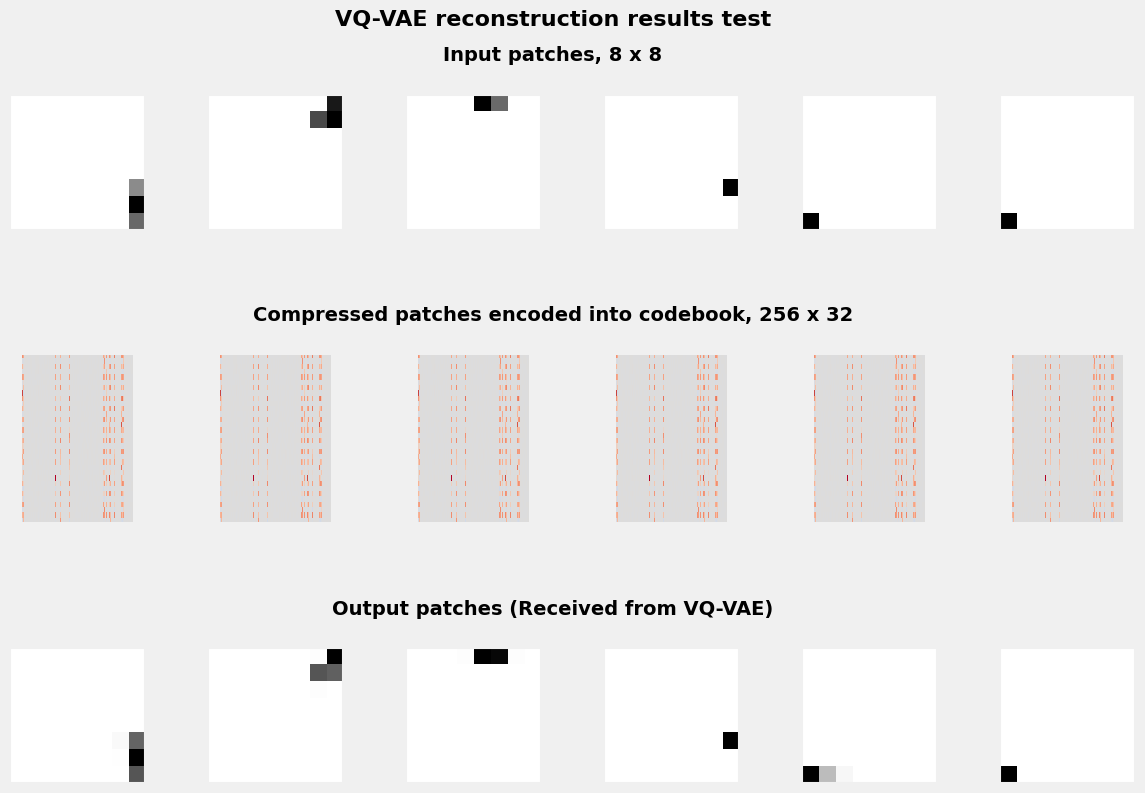

In [ ]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

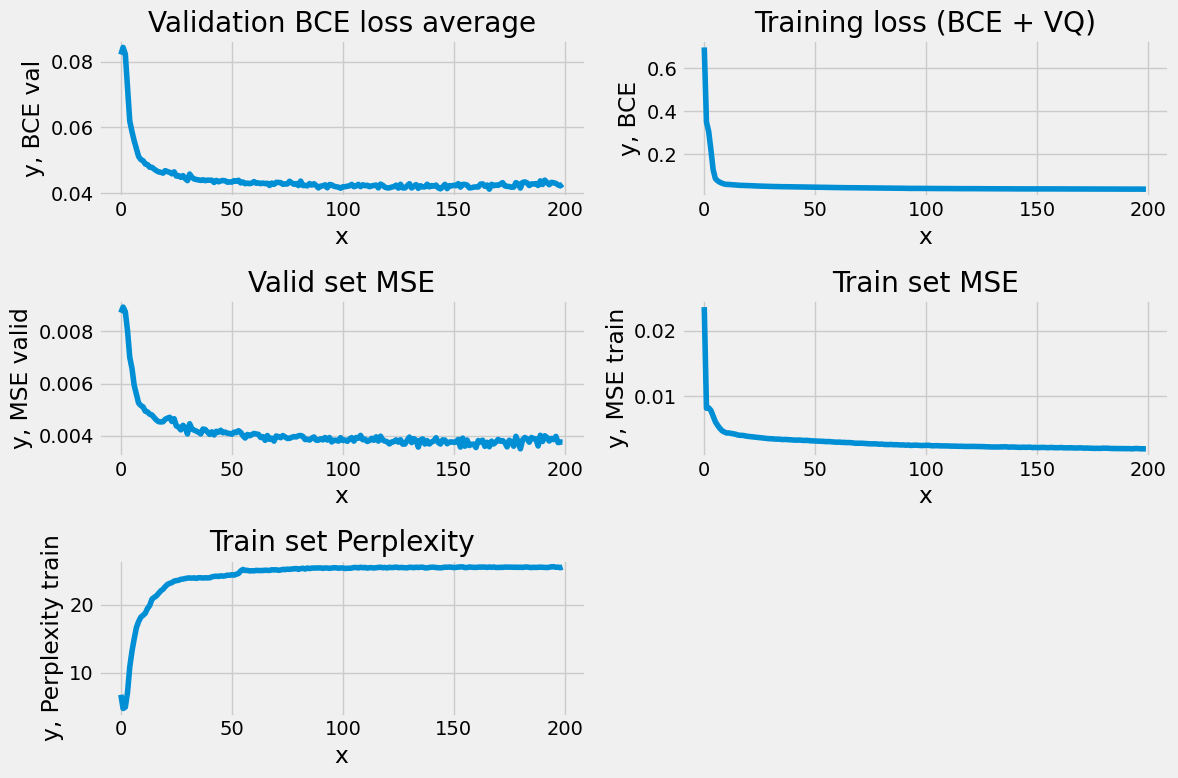

In [ ]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)


In [ ]:
patches_before_train

[array([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.63529414,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ]], dtype=float32),
 array([[0.        , 0.        , 0.        , 0.        , 0.    